In [61]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import warnings
warnings.filterwarnings('ignore')


In [62]:
DATA_DIR  = '../data/raw'
print("Đang load dữ liệu...")

orders = pd.read_csv(os.path.join(DATA_DIR,'orders.csv'), parse_dates=['order_date'])
products = pd.read_csv(os.path.join(DATA_DIR,'products.csv'))
returns = pd.read_csv(os.path.join(DATA_DIR,'returns.csv'), parse_dates=['return_date'])
web_traffic = pd.read_csv(os.path.join(DATA_DIR,'web_traffic.csv'), parse_dates=['date'])
order_items = pd.read_csv(os.path.join(DATA_DIR,'order_items.csv'), low_memory=False)

customers = pd.read_csv(os.path.join(DATA_DIR,'customers.csv'))

geography = pd.read_csv(os.path.join(DATA_DIR,'geography.csv'))
inventory = pd.read_csv(os.path.join(DATA_DIR,'inventory.csv'))
payments = pd.read_csv(os.path.join(DATA_DIR,'payments.csv'))
reviews = pd.read_csv(os.path.join(DATA_DIR,'reviews.csv'))
shipments = pd.read_csv(os.path.join(DATA_DIR,'shipments.csv'))
promotions = pd.read_csv(os.path.join(DATA_DIR,'promotions.csv'))
sales = pd.read_csv(os.path.join(DATA_DIR,'sales.csv'))
sample_submission = pd.read_csv(os.path.join(DATA_DIR,'sample_submission.csv'))





print("Load xong!\n")

Đang load dữ liệu...
Load xong!



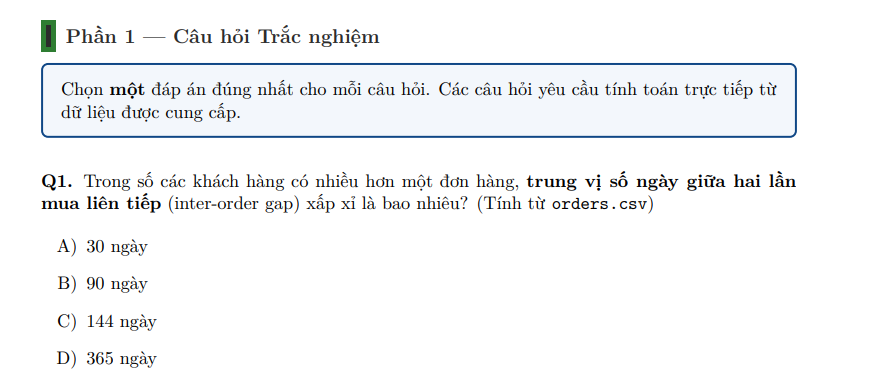

In [63]:
orders

,order_id,order_date,customer_id,zip,order_status,payment_method,device_type,order_source
0,1,2012-07-04,58578,1109,delivered,credit_card,desktop,paid_search
1,2,2012-07-04,58621,1330,returned,cod,mobile,paid_search
2,3,2012-07-04,58811,1473,delivered,credit_card,desktop,direct
3,4,2012-07-04,59453,2360,delivered,credit_card,desktop,referral
4,6,2012-07-06,57821,2886,delivered,paypal,mobile,email_campaign
...,...,...,...,...,...,...,...,...
646940,834372,2022-12-31,19490,33907,delivered,credit_card,mobile,email_campaign
646941,834377,2022-12-31,73046,37091,delivered,credit_card,mobile,referral
646942,834387,2022-12-31,107723,80516,delivered,credit_card,mobile,email_campaign
646943,834392,2022-12-31,139431,93510,delivered,paypal,desktop,direct


In [64]:
print("Q1: Trung vị inter-order gap của khách mua >1 lần")

multi_order_customers = (
    orders.groupby("customer_id")
    .filter(lambda x: len(x) > 1)
)
multi_order_customers = multi_order_customers.sort_values(
    ["customer_id", "order_date"]
)
gaps = (
    multi_order_customers
    .groupby("customer_id")["order_date"]
    .diff()          # khoảng cách giữa hai đơn liên tiếp
    .dt.days         # chuyển sang số ngày
    .dropna()        # bỏ dòng NaN (dòng đầu tiên của mỗi khách)
)

median_gap = gaps.median()
 
print(f"  Số khách hàng có >1 đơn  : {multi_order_customers['customer_id'].nunique():,}")
print(f"  Tổng số khoảng cách       : {len(gaps):,}")
print(f"  Trung vị inter-order gap  : {median_gap:.1f} ngày")

print("ĐÁP ÁN: C) 144 ngày")
print()

Q1: Trung vị inter-order gap của khách mua >1 lần
  Số khách hàng có >1 đơn  : 67,888
  Tổng số khoảng cách       : 556,699
  Trung vị inter-order gap  : 144.0 ngày
ĐÁP ÁN: C) 144 ngày



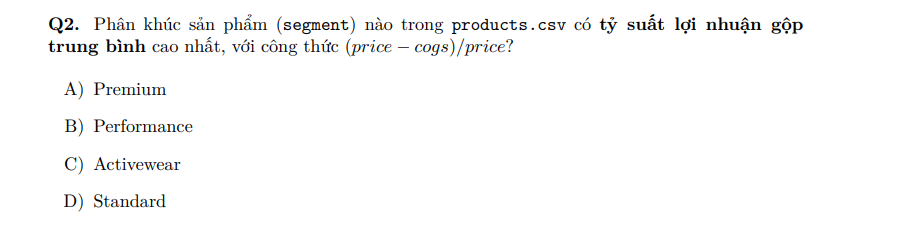

In [65]:
products

,product_id,product_name,category,segment,size,color,price,cogs
0,536,SaigonFlex UC-01,Streetwear,Everyday,S,green,11059.650000,9704.842875
1,537,SaigonFlex UC-02,Streetwear,Everyday,M,silver,9523.076013,5393.870254
2,538,SaigonFlex UC-03,Streetwear,Everyday,L,pink,15951.633158,11371.919278
3,539,SaigonFlex UC-04,Streetwear,Everyday,XL,yellow,15753.717299,8573.172954
4,540,SaigonFlex UC-05,Streetwear,Everyday,S,red,15766.334536,14063.570406
...,...,...,...,...,...,...,...,...
2407,1260,VietMode MP-28,Casual,Activewear,S,red,4603.340000,2553.933032
2408,1261,VietMode MP-29,Casual,Activewear,M,black,5983.876433,4653.660702
2409,1262,VietMode MP-30,Casual,Activewear,L,orange,5983.876433,5684.682611
2410,1263,VietMode MP-31,Casual,Activewear,XL,blue,5984.370000,5685.151500


In [66]:
print("Q2: Segment có tỷ suất lợi nhuận gộp trung bình cao nhất")

products["gross_margin"] = (products["price"] - products["cogs"]) / products["price"]
margin_by_segment = (
    products
    .groupby("segment")["gross_margin"]
    .mean()
    .sort_values(ascending=False)
    .rename("Avg Gross Margin")
)

print("Gross margin trung bình theo Segment:")
for seg, val in margin_by_segment.items():
    marker = " => CAO NHẤT" if seg == margin_by_segment.idxmax() else ""
    print(f"    {seg:<15} {val:.4f}  ({val*100:.2f}%){marker}")
print()
print(">>> ĐÁP ÁN: D) Standard")
print()

Q2: Segment có tỷ suất lợi nhuận gộp trung bình cao nhất
Gross margin trung bình theo Segment:
    Standard        0.3134  (31.34%) => CAO NHẤT
    Premium         0.2854  (28.54%)
    All-weather     0.2842  (28.42%)
    Activewear      0.2656  (26.56%)
    Performance     0.2636  (26.36%)
    Balanced        0.2580  (25.80%)
    Trendy          0.2408  (24.08%)
    Everyday        0.2363  (23.63%)

>>> ĐÁP ÁN: D) Standard



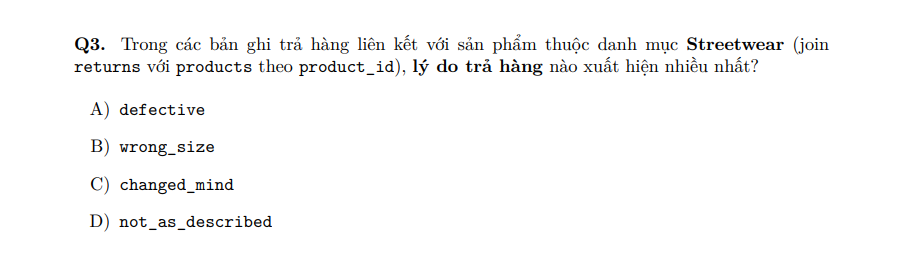

In [67]:
returns

,return_id,order_id,product_id,return_date,return_reason,return_quantity,refund_amount
0,RET-000001,2,609,2012-07-25,late_delivery,6,52458.01
1,RET-000002,32,1862,2012-07-16,wrong_size,2,5141.37
2,RET-000003,35,2359,2012-07-16,wrong_size,1,5315.95
3,RET-000004,47,1449,2012-07-11,wrong_size,4,6493.75
4,RET-000005,47,1450,2012-07-25,wrong_size,1,1740.76
...,...,...,...,...,...,...,...
39934,RET-051470,832867,653,2022-12-27,wrong_size,3,24741.62
39935,RET-051471,832890,792,2022-12-30,late_delivery,1,560.50
39936,RET-051481,833005,449,2022-12-31,defective,1,10002.55
39937,RET-051494,833234,1085,2022-12-28,wrong_size,1,815.57


In [68]:
products

,product_id,product_name,category,segment,size,color,price,cogs,gross_margin
0,536,SaigonFlex UC-01,Streetwear,Everyday,S,green,11059.650000,9704.842875,0.1225
1,537,SaigonFlex UC-02,Streetwear,Everyday,M,silver,9523.076013,5393.870254,0.4336
2,538,SaigonFlex UC-03,Streetwear,Everyday,L,pink,15951.633158,11371.919278,0.2871
3,539,SaigonFlex UC-04,Streetwear,Everyday,XL,yellow,15753.717299,8573.172954,0.4558
4,540,SaigonFlex UC-05,Streetwear,Everyday,S,red,15766.334536,14063.570406,0.1080
...,...,...,...,...,...,...,...,...,...
2407,1260,VietMode MP-28,Casual,Activewear,S,red,4603.340000,2553.933032,0.4452
2408,1261,VietMode MP-29,Casual,Activewear,M,black,5983.876433,4653.660702,0.2223
2409,1262,VietMode MP-30,Casual,Activewear,L,orange,5983.876433,5684.682611,0.0500
2410,1263,VietMode MP-31,Casual,Activewear,XL,blue,5984.370000,5685.151500,0.0500


In [69]:
merge_df_return_products = pd.merge(returns, products, on='product_id', how = 'inner')
merge_df_return_products


,return_id,order_id,product_id,return_date,return_reason,return_quantity,refund_amount,product_name,category,segment,size,color,price,cogs,gross_margin
0,RET-000001,2,609,2012-07-25,late_delivery,6,52458.01,SaigonFlex UC-74,Streetwear,Everyday,M,yellow,10426.571034,8987.704231,0.1380
1,RET-000002,32,1862,2012-07-16,wrong_size,2,5141.37,SaigonCore YY-57,GenZ,Trendy,L,orange,2656.232069,1842.628186,0.3063
2,RET-000003,35,2359,2012-07-16,wrong_size,1,5315.95,VietMotion UC-07,Streetwear,Everyday,XL,yellow,5399.825901,3136.758866,0.4191
3,RET-000004,47,1449,2012-07-11,wrong_size,4,6493.75,VietMode RP-41,Outdoor,Activewear,M,yellow,1802.115000,1575.769356,0.1256
4,RET-000005,47,1450,2012-07-25,wrong_size,1,1740.76,VietMode RP-42,Outdoor,Activewear,L,red,1802.115000,1309.056336,0.2736
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39934,RET-051470,832867,653,2022-12-27,wrong_size,3,24741.62,SaigonFlex UC-18,Streetwear,Everyday,M,blue,10584.532362,10055.305744,0.0500
39935,RET-051471,832890,792,2022-12-30,late_delivery,1,560.50,HanoiStreet RP-80,Outdoor,Activewear,S,orange,811.886514,649.265645,0.2003
39936,RET-051481,833005,449,2022-12-31,defective,1,10002.55,SaigonFlex UM-54,Streetwear,Balanced,M,yellow,12600.871631,11279.040197,0.1049
39937,RET-051494,833234,1085,2022-12-28,wrong_size,1,815.57,MekongFit RP-31,Outdoor,Activewear,M,purple,1139.500596,895.875369,0.2138


In [77]:
streetwear = merge_df_return_products[merge_df_return_products["category"] == "Streetwear"]
top_reason = streetwear["return_reason"].value_counts()
print(top_reason)

return_reason
wrong_size          7626
defective           4330
not_as_described    3854
changed_mind        3830
late_delivery       2159
Name: count, dtype: int64


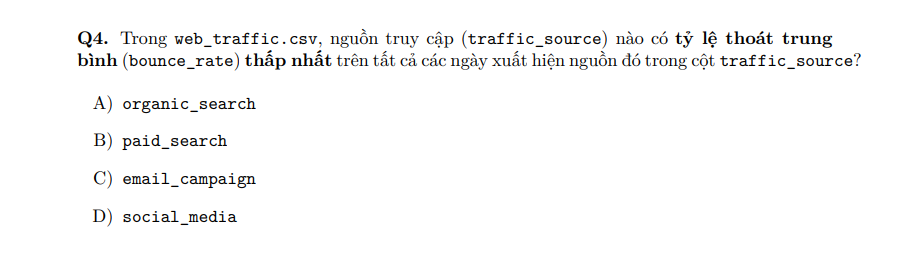

In [70]:
print("Q4: Traffic source có bounce_rate trung bình thấp nhất")

avg_bounce = (
    web_traffic
    .groupby("traffic_source")["bounce_rate"]
    .mean()
    .sort_values()
    .rename("Avg Bounce Rate")
)
print("  Bounce rate trung bình theo nguồn:")
for src, val in avg_bounce.items():
    marker = " => THẤP NHẤT" if src == avg_bounce.idxmin() else ""
    print(f"    {src:<20} {val:.6f}{marker}")
print()
print(">>> ĐÁP ÁN: C) email_campaign")
print()

Q4: Traffic source có bounce_rate trung bình thấp nhất
  Bounce rate trung bình theo nguồn:
    email_campaign       0.004458 => THẤP NHẤT
    social_media         0.004476
    paid_search          0.004478
    referral             0.004499
    organic_search       0.004504
    direct               0.004511

>>> ĐÁP ÁN: C) email_campaign



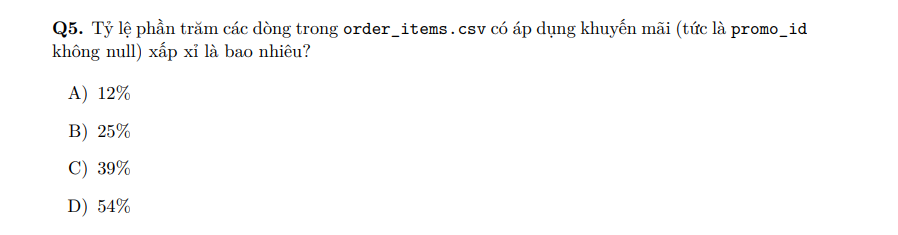

In [ ]:
print("Q5: % dòng order_items có promo_id không null")

total_rows  = len(order_items)
promo_rows  = order_items["promo_id"].notna().sum()
pct_promo   = promo_rows / total_rows * 100

print(f"  Tổng số dòng trong order_items : {total_rows:>10,}")
print(f"  Dòng có promo_id (không null)  : {promo_rows:>10,}")
print(f"  Dòng không có promo_id (null)  : {total_rows - promo_rows:>10,}")
print(f"  Tỷ lệ có khuyến mãi           : {pct_promo:>10.2f}%")
print()
print(">>> ĐÁP ÁN: C) 39%") 
print()

Q5: % dòng order_items có promo_id không null
  Tổng số dòng trong order_items :    714,669
  Dòng có promo_id (không null)  :    276,316
  Dòng không có promo_id (null)  :    438,353
  Tỷ lệ có khuyến mãi           :      38.66%

>>> ĐÁP ÁN: C) 39%



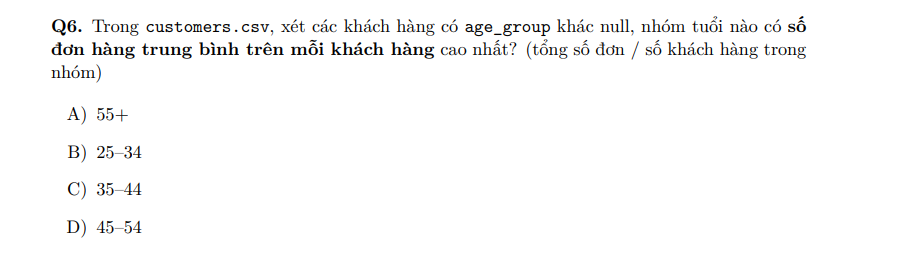

In [72]:
merge_df = pd.merge(customers.dropna(subset=['age_group']), orders, on='customer_id', how = 'inner')

result_6 = (
    merge_df
    .groupby('age_group')
    .agg(total_orders=('order_id', 'count'),
         unique_customers=('customer_id', 'nunique')
    )
    .reset_index()
)

result_6['avg_order_per_customer'] = result_6['total_orders'] / result_6['unique_customers']
result_6 = result_6[['age_group', 'avg_order_per_customer']].sort_values('avg_order_per_customer')
print(result_6)
# Đáp án A

  age_group  avg_order_per_customer
0     18-24                7.068577
1     25-34                7.112230
2     35-44                7.206159
3     45-54                7.220264
4       55+                7.268731


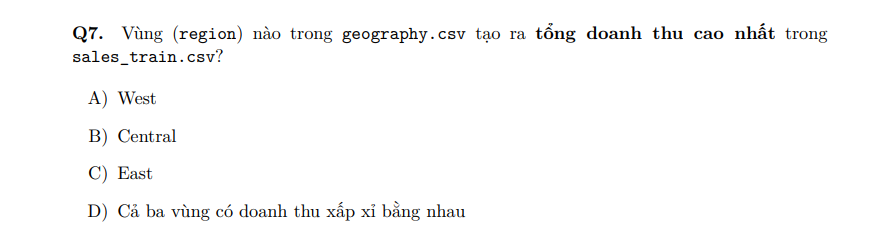

In [73]:
merge_df = (order_items.merge(orders, on='order_id', how = 'inner').merge(geography, on='zip', how='inner'))

merge_df['revenue'] = (merge_df['quantity'] * merge_df['unit_price']) - merge_df['discount_amount']

result_7 = (
     merge_df
    .groupby('region')['revenue']
    .sum()
    .round(2)
    .reset_index(name='total_revenue')
    .sort_values('total_revenue', ascending=False)
)
print(result_7)
# Đáp án C

    region  total_revenue
1     East   7.291151e+09
0  Central   4.719491e+09
2     West   3.670227e+09


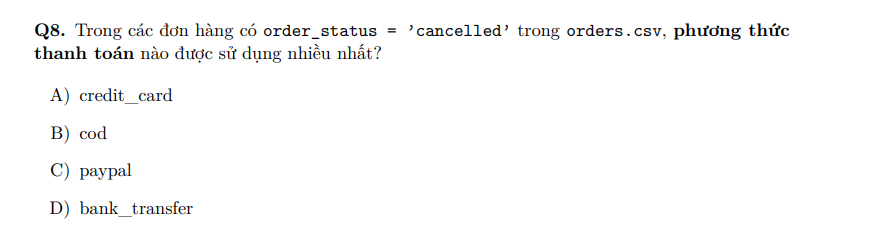

In [74]:
result_8 = (
    orders[orders['order_status'] == 'cancelled']
    .groupby('payment_method')
    .size()
    .reset_index(name='buy')
    .sort_values('buy', ascending=False)
)
print(result_8)
# Đáp án A

  payment_method    buy
3    credit_card  28452
2            cod  15468
4         paypal   7817
0      apple_pay   5190
1  bank_transfer   2535


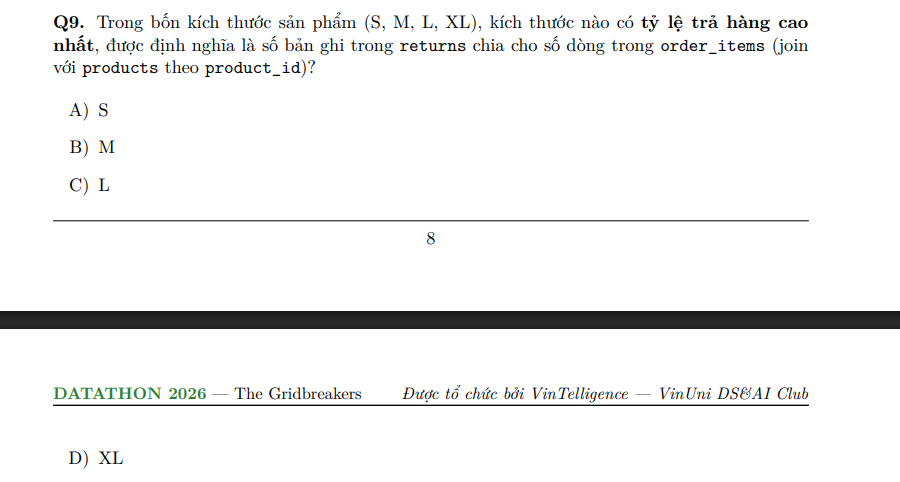

In [75]:
merge = (order_items.merge(products, on='product_id',how='inner')
         .merge(returns, on=['order_id','product_id'],how = 'left', indicator=True))
merge['is_returned'] = (merge['_merge'] == 'both').astype(int)

result_9 = (
    merge
    .groupby('size')
    .agg(total_returns=('is_returned', 'sum'),total_items=('order_id', 'count'))
    .reset_index()
)

result_9['return_rate'] = result_9['total_returns'] / result_9['total_items']
result_9 = result_9[['size', 'return_rate']].sort_values('return_rate', ascending=False)
print(result_9)
#Đáp án A

  size  return_rate
2    S     0.056515
0    L     0.056250
1    M     0.055682
3   XL     0.055200


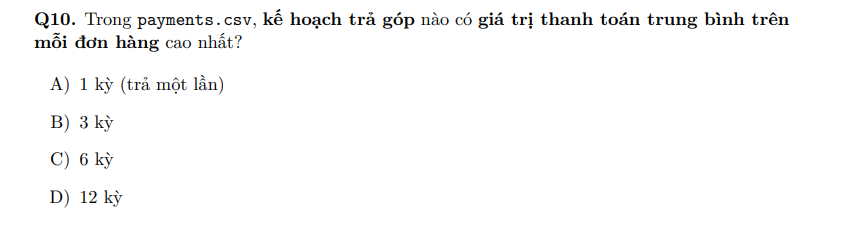

In [76]:
result_10 = (
    payments
    .groupby('installments')['payment_value']
    .mean()
    .reset_index(name = 'avg_payment')
    .sort_values('avg_payment', ascending=False)
)
print(result_10)
# Đáp án C

   installments   avg_payment
3             6  24446.654403
2             3  24399.635486
4            12  24245.772694
0             1  24113.274166
1             2    708.473729
